<a href="https://colab.research.google.com/github/rafaelespinosacastaneda/sdl-workshops/blob/main/bayesian_opt/bayesian_optimization_tutorial_RMSE_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Optimization with an OT-2 Color-Mixing Simulator

Self-driving laboratories combine automated experimentation with algorithms that decide what experiment to run next. In this tutorial, we use a **simulator of an Opentrons OT-2 liquid-handling experiment**. The simulated OT-2 mixes red, yellow, and blue dyes, measures the resulting mixture with an eight-channel spectrometer, and returns the measurement to the optimization algorithm.

The goal is to match a target spectrum while using as few experiments as possible. We will compare three strategies:

1. random sampling;
2. greedy coordinate search;
3. Bayesian optimization with a Gaussian Process and Expected Improvement.



## 1. OT-2 simulator

The simulator represents the main steps of the experiment:

```text
propose red/yellow/blue liquid volumes
                ↓
       OT-2 simulator mixes dyes
                ↓
   eight-channel spectrum is measured
                ↓
 compare spectrum with target spectrum
                ↓
        scalar optimization error
```

The spectral response follows a Beer-Lambert model. The simulator also includes two experimental effects:

- **systematic error:** stray light changes with the column of the 96-well plate;
- **random error:** sensor noise changes from measurement to measurement.

The tutorial keeps the total liquid volume at or below 300 µL and avoids volumes below 10 µL, where pipetting error would typically become more important.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

SEED = 0
QUOTA = 26

SENSOR_CHANNELS = [
    "ch410", "ch440", "ch470", "ch510",
    "ch550", "ch583", "ch620", "ch670",
]
WAVELENGTHS = np.array([410, 440, 470, 510, 550, 583, 620, 670], dtype=float)
REFERENCE_SPECTRUM = np.array(
    [1200, 1600, 1900, 2400, 2600, 2300, 2000, 1500],
    dtype=float,
)

VOLUME_MIN = 10
VOLUME_MAX = 280
TOTAL_VOLUME_MAX = 300
MIX_CHANNELS = ["R", "Y", "B"]


def _band(peak_nm, width_nm, amplitude):
    return amplitude * np.exp(-0.5 * ((WAVELENGTHS - peak_nm) / width_nm) ** 2)


DYE_ABSORPTIVITY = {
    "R": _band(505.0, 58.0, 1.15) + _band(560.0, 40.0, 0.35),
    "Y": _band(428.0, 45.0, 1.00) + _band(470.0, 35.0, 0.20),
    "B": _band(630.0, 60.0, 1.35) + _band(590.0, 45.0, 0.30),
}

STRAY_MIN = 0.004
STRAY_MAX = 0.009
READ_NOISE_FRAC = 0.05
_sim_rng = np.random.default_rng(SEED)


def reset_simulator(seed=SEED):
    global _sim_rng
    _sim_rng = np.random.default_rng(seed)


def plate_position(well_index):
    """Return the (row, column) of a 96-well plate for a 1-based experiment index."""
    i = (int(well_index) - 1) % 96
    row, col = i // 12, i % 12
    return "ABCDEFGH"[row], col + 1


def _ideal_spectrum(r_vol, y_vol, b_vol):
    total = float(r_vol) + float(y_vol) + float(b_vol)
    fractions = np.array([r_vol, y_vol, b_vol], dtype=float) / total
    absorbance = (
        DYE_ABSORPTIVITY["R"] * fractions[0]
        + DYE_ABSORPTIVITY["Y"] * fractions[1]
        + DYE_ABSORPTIVITY["B"] * fractions[2]
    )
    return REFERENCE_SPECTRUM * 10.0 ** (-absorbance)


def simulate_ot2(r_vol, y_vol, b_vol, well_index=1):
    """Simulate one OT-2 color-mixing experiment and return eight sensor channels."""
    _, col = plate_position(well_index)

    stray = (
        STRAY_MIN + (STRAY_MAX - STRAY_MIN) * (col - 1) / 11.0
    ) * REFERENCE_SPECTRUM
    noise = _sim_rng.normal(0.0, READ_NOISE_FRAC * REFERENCE_SPECTRUM)

    counts = np.clip(
        np.round(_ideal_spectrum(r_vol, y_vol, b_vol) + stray + noise),
        1,
        65535,
    )

    return {
        "Message": "Success",
        "Sensor Data": {
            channel: float(value)
            for channel, value in zip(SENSOR_CHANNELS, counts)
        },
    }


print(f"OT-2 simulator ready. Experimental budget: {QUOTA} experiments.")

OT-2 simulator ready. Experimental budget: 26 experiments.


### 1.1 Define a target spectrum

The optimization algorithm is not given the target liquid volumes. It only receives an experimental input and the resulting spectral error.

For the tutorial, we create one fixed target measurement with the OT-2 simulator. The target is then held constant for every search strategy.

In [ ]:
target_rng = np.random.default_rng(SEED)

# Sample random proportions uniformly over the simplex
fractions = target_rng.dirichlet([1, 1, 1])

# Convert proportions to volumes while reserving the minimum volume
remaining = TOTAL_VOLUME_MAX - 3 * VOLUME_MIN

volumes = VOLUME_MIN + fractions * remaining

# Round to integers
volumes = np.floor(volumes).astype(int)

# Correct rounding so the total is exactly 300 µL
difference = TOTAL_VOLUME_MAX - volumes.sum()

for i in range(difference):
    volumes[i % 3] += 1

TARGET_VOLUMES = {
    "R": int(volumes[0]),
    "Y": int(volumes[1]),
    "B": int(volumes[2]),
}


print(TARGET_VOLUMES)
print("Total:", sum(TARGET_VOLUMES.values()))


reset_simulator(SEED + 1)
target_response = simulate_ot2(**{
    "r_vol": TARGET_VOLUMES["R"],
    "y_vol": TARGET_VOLUMES["Y"],
    "b_vol": TARGET_VOLUMES["B"],
}, well_index=1)
TARGET_SPECTRUM = np.array(
    [target_response["Sensor Data"][c] for c in SENSOR_CHANNELS],
    dtype=float,
)
reset_simulator(SEED)

pd.DataFrame({
    "wavelength_nm": WAVELENGTHS.astype(int),
    "target_counts": TARGET_SPECTRUM,
})

{'R': 117, 'Y': 170, 'B': 13}
Total: 300


,wavelength_nm,target_counts
0,410,284.0
1,440,290.0
2,470,297.0
3,510,347.0
4,550,914.0
5,583,1075.0
6,620,1290.0
7,670,1355.0


### 1.2 Observe one simulated OT-2 experiment

Each experimental input is a set of three liquid volumes in microliters:
$
\mathbf{x}=(R,Y,B).
$

The simulator returns eight sensor intensities. Those eight values form the spectrum that will be compared with the target.

In [ ]:
#Fill the _ blanks with example red, yellow and blue liquid quantities
example = simulate_ot2(_, _, _, well_index=1)
print("Mixture: R=100 µL, Y=100 µL, B=100 µL")
print("Plate position:", plate_position(1))
print("Sensor data:")
for channel in SENSOR_CHANNELS:
    print(f"  {channel}: {example['Sensor Data'][channel]:.0f}")

reset_simulator(SEED)

Mixture: R=100 µL, Y=100 µL, B=100 µL
Plate position: ('A', 1)
Sensor data:
  ch410: 464
  ch440: 419
  ch470: 517
  ch510: 605
  ch550: 506
  ch583: 526
  ch620: 623
  ch670: 688


## 2. What exactly are we optimizing?

The simulator returns an eight-channel spectrum, we define our Bayesian optimization with a **single scalar objective**. We therefore compare the measured spectrum with the target spectrum using the **root mean squared error (RMSE)** across the eight normalized sensor channels.

For a measured spectrum \(s\) and target spectrum \(t\), the objective is

$
\mathrm{RMSE}(s,t)
=
\sqrt{
\frac{1}{8}
\sum_{i=1}^{8}
\left(
\frac{s_i}{I_{0,i}}
-
\frac{t_i}{I_{0,i}}
\right)^2
},
$

where $I_{0,i}$ is the reference-spectrum value for channel $i$. Normalizing each channel by its reference value prevents channels with larger raw counts from dominating the error.

We optimize

$
\boxed{\min_{R,Y,B} f(R,Y,B)}
$

subject to

$
R,Y,B \geq 10\;\mu\mathrm{L},
\qquad
R+Y+B \leq 300\;\mu\mathrm{L}.
$

Here, $f(R,Y,B)$ is the RMSE between the simulated measured spectrum and the fixed target spectrum. **Smaller is better**, and an RMSE of zero would mean an exact channel-by-channel match after normalization.

The optimizer learns only from observations of the form

$
(R,Y,B) \longrightarrow f(R,Y,B).
$

In [ ]:
# Fill the blank. We defined previously a number of experiments. Hint the variable name
# starts with   QUO
NUM_EXPERIMENTS = _

lower = np.full(3, VOLUME_MIN, dtype=float)
upper = np.full(3, VOLUME_MAX, dtype=float)
span = upper - lower

_campaign_well = 0


def normalize_volumes(X):
    """Map liquid volumes to [0, 1]^3 for Gaussian Process fitting."""
    X = np.asarray(X, dtype=float)
    return (X - lower) / span


def as_volume_dict(x):
    """Convert a proposed point into integer liquid volumes and validate it."""
    x = np.asarray(x, dtype=float)
    x = np.clip(np.rint(x), lower, upper).astype(int)
    if x.sum() > TOTAL_VOLUME_MAX:
        raise ValueError("Total liquid volume exceeds 300 µL.")
    return {c: int(v) for c, v in zip(MIX_CHANNELS, x)}


def spectrum_vector(response):
    return np.array(
        [response["Sensor Data"][c] for c in SENSOR_CHANNELS],
        dtype=float,
    )



def spectral_rmse(spectrum_a, spectrum_b):
    """RMSE across the eight sensor channels after reference normalization."""
    a = np.asarray(spectrum_a, dtype=float) / REFERENCE_SPECTRUM
    b = np.asarray(spectrum_b, dtype=float) / REFERENCE_SPECTRUM
    return float(np.sqrt(np.mean((a - b) ** 2)))

def begin_campaign(seed=SEED):
    """Reset sensor noise and plate position for a fair comparison between methods."""
    global _campaign_well
    _campaign_well = 0
    reset_simulator(seed)


def run_experiment(x):
    """Run one simulated OT-2 experiment and return its spectral RMSE."""
    global _campaign_well
    params = as_volume_dict(x)
    _campaign_well += 1

    response = simulate_ot2(
        params["R"], params["Y"], params["B"],
        well_index=_campaign_well,
    )
    measured = spectrum_vector(response)
    error = spectral_rmse(measured, TARGET_SPECTRUM)

    row, col = plate_position(_campaign_well)
    return params, error, f"{row}{col}"


def records_to_df(records, method):
    df = pd.DataFrame(records)
    df["iteration"] = np.arange(1, len(df) + 1)
    df["best_so_far"] = df["rmse"].cummin()
    df["method"] = method
    return df


def sample_feasible_points(rng, n_points):
    """Uniformly sample integer mixtures satisfying the tutorial volume constraints."""
    points = []
    seen = set()
    while len(points) < n_points:
        x = rng.integers(VOLUME_MIN, VOLUME_MAX + 1, size=3)
        key = tuple(x.tolist())
        if x.sum() <= TOTAL_VOLUME_MAX and key not in seen:
            seen.add(key)
            points.append(x)
    return np.asarray(points)

## 3. Baseline A — random sampling

Random search does not build a model. At every iteration, it draws a new feasible mixture and runs the OT-2 simulator.

This provides a reference for the question: **how well can we do with the same experimental budget if we do not learn from previous measurements?**

In [ ]:
def run_random_search(n_experiments=NUM_EXPERIMENTS, seed=SEED):
    begin_campaign(seed)
    rng = np.random.default_rng(seed)
    records = []

    for i, x in enumerate(sample_feasible_points(rng, n_experiments), start=1):
        params, error, well = run_experiment(x)
        records.append({**params, "well": well, "rmse": error})
        print(f"Random {i:02d}/{n_experiments}: {params} -> error = {error:.4f}")

    return records_to_df(records, "Random")

# Fill the blank... Hint: what function returns random?
random_df = _

Random 01/26: {'R': 83, 'Y': 93, 'B': 21} -> error = 0.0771
Random 02/26: {'R': 30, 'Y': 14, 'B': 57} -> error = 0.4016
Random 03/26: {'R': 31, 'Y': 91, 'B': 140} -> error = 0.3473
Random 04/26: {'R': 124, 'Y': 119, 'B': 17} -> error = 0.0838
Random 05/26: {'R': 11, 'Y': 43, 'B': 12} -> error = 0.1241
Random 06/26: {'R': 23, 'Y': 32, 'B': 112} -> error = 0.3981
Random 07/26: {'R': 31, 'Y': 122, 'B': 86} -> error = 0.2652
Random 08/26: {'R': 41, 'Y': 45, 'B': 207} -> error = 0.4353
Random 09/26: {'R': 34, 'Y': 215, 'B': 50} -> error = 0.1711
Random 10/26: {'R': 82, 'Y': 27, 'B': 144} -> error = 0.3763
Random 11/26: {'R': 80, 'Y': 83, 'B': 75} -> error = 0.2215
Random 12/26: {'R': 71, 'Y': 43, 'B': 43} -> error = 0.2355
Random 13/26: {'R': 72, 'Y': 170, 'B': 16} -> error = 0.0746
Random 14/26: {'R': 40, 'Y': 12, 'B': 37} -> error = 0.3406
Random 15/26: {'R': 108, 'Y': 39, 'B': 31} -> error = 0.1639
Random 16/26: {'R': 120, 'Y': 26, 'B': 139} -> error = 0.3872
Random 17/26: {'R': 95, 'Y':

## 4. Baseline B — greedy coordinate search

A simple alternative is to change **one liquid volume at a time**.

We begin from a feasible mixture. We then sweep red, yellow, and blue sequentially while holding the other two volumes fixed. After each sweep, the method keeps the value with the smallest measured error.

The 26-experiment budget is divided as **9 red tests + 9 yellow tests + 8 blue tests**.

This method can improve on its measurements, but it does not model interactions between the three liquid volumes.

In [ ]:
def run_greedy_coordinate_search(points_per_channel=(9, 9, 8), seed=SEED):
    begin_campaign(seed)
    current = np.array([100, 100, 100], dtype=int)
    records = []

    for dim, (channel, n_points) in enumerate(zip(MIX_CHANNELS, points_per_channel)):
        other_total = current.sum() - current[dim]
        feasible_max = min(VOLUME_MAX, TOTAL_VOLUME_MAX - other_total)
        test_values = np.unique(
            np.rint(np.linspace(VOLUME_MIN, feasible_max, n_points)).astype(int)
        )

        best_error = np.inf
        best_value = current[dim]
        print(f"\nOptimizing {channel} while holding the other volumes fixed...")

        for value in test_values:
            candidate = current.copy()
            candidate[dim] = value
            params, error, well = run_experiment(candidate)
            records.append({**params, "well": well, "rmse": error})
            print(f"  {params} -> error = {error:.4f}")

            if error < best_error:
                best_error = error
                best_value = value

        current[dim] = best_value
        print(f"Best {channel} volume from this sweep: {best_value} µL")

    return records_to_df(records, "Greedy coordinate")

# Fill the blank... Hint: what function returns greedy?
greedy_df = _


Optimizing R while holding the other volumes fixed...
  {'R': 10, 'Y': 100, 'B': 100} -> error = 0.2998
  {'R': 21, 'Y': 100, 'B': 100} -> error = 0.3280
  {'R': 32, 'Y': 100, 'B': 100} -> error = 0.2985
  {'R': 44, 'Y': 100, 'B': 100} -> error = 0.2961
  {'R': 55, 'Y': 100, 'B': 100} -> error = 0.2591
  {'R': 66, 'Y': 100, 'B': 100} -> error = 0.2474
  {'R': 78, 'Y': 100, 'B': 100} -> error = 0.2802
  {'R': 89, 'Y': 100, 'B': 100} -> error = 0.2610
  {'R': 100, 'Y': 100, 'B': 100} -> error = 0.2721
Best R volume from this sweep: 66 µL

Optimizing Y while holding the other volumes fixed...
  {'R': 66, 'Y': 10, 'B': 100} -> error = 0.3882
  {'R': 66, 'Y': 26, 'B': 100} -> error = 0.3437
  {'R': 66, 'Y': 41, 'B': 100} -> error = 0.3405
  {'R': 66, 'Y': 56, 'B': 100} -> error = 0.3222
  {'R': 66, 'Y': 72, 'B': 100} -> error = 0.3131
  {'R': 66, 'Y': 88, 'B': 100} -> error = 0.2557
  {'R': 66, 'Y': 103, 'B': 100} -> error = 0.2871
  {'R': 66, 'Y': 118, 'B': 100} -> error = 0.2338
  {'R': 

## 5. Bayesian optimization: the algorithm

Bayesian optimization is useful when experiments are expensive and we want each new experiment to be informed by all measurements collected so far.

We use:

- **surrogate model:** Gaussian Process regression with an RBF kernel;
- **acquisition function:** Expected Improvement (EI).

Suppose we have measured

$
\mathcal{D}_t=\{(\mathbf{x}_1,y_1),\ldots,(\mathbf{x}_t,y_t)\},
$

where $\mathbf{x}_i=(R_i,Y_i,B_i)$ and $y_i=f(\mathbf{x}_i)$. The Gaussian Process predicts

$
f(\mathbf{x})\mid\mathcal{D}_t
\sim
\mathcal{N}(\mu_t(\mathbf{x}),\sigma_t^2(\mathbf{x})).
$

The predicted mean supports **exploitation**, while predictive uncertainty supports **exploration**.

### 5.1 Expected Improvement for minimization

Let

$
y_{\mathrm{best}}=\min(y_1,\ldots,y_t).
$

For a candidate $\mathbf{x}$, Expected Improvement is

$
EI(\mathbf{x})=
(y_{\mathrm{best}}-\mu(\mathbf{x})-\xi)\Phi(Z)
+\sigma(\mathbf{x})\phi(Z),
$

with

$
Z=\frac{y_{\mathrm{best}}-\mu(\mathbf{x})-\xi}{\sigma(\mathbf{x})}.
$

We select the feasible candidate with the largest EI:

$
\boxed{\mathbf{x}_{t+1}=\arg\max_{\mathbf{x}}EI(\mathbf{x})}.
$

In [ ]:
def fit_gaussian_process(X, y):
    Xn = normalize_volumes(X)

    kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * RBF(
        length_scale=[0.25, 0.25, 0.25],
        length_scale_bounds="fixed",
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        optimizer=None,
    )
    gp.fit(Xn, y)
    return gp


def expected_improvement(X_candidates, gp, y_best, xi=0.01):
    Xn = normalize_volumes(X_candidates)
    mu, sigma = gp.predict(Xn, return_std=True)

    improvement = y_best - mu - xi
    ei = np.zeros_like(mu)
    nonzero = sigma > 1e-12
    z = improvement[nonzero] / sigma[nonzero]

    ei[nonzero] = (
        improvement[nonzero] * norm.cdf(z)
        + sigma[nonzero] * norm.pdf(z)
    )
    return ei, mu, sigma


def make_candidate_pool(rng, n_candidates=3000):
    return sample_feasible_points(rng, n_candidates)

### 5.2 The Bayesian optimization loop in plain language

Every iteration performs the same steps:

1. **Fit** the Gaussian Process to all volume/error measurements collected so far.
2. **Generate feasible candidate mixtures**.
3. **Predict** the mean error and uncertainty for each candidate.
4. **Calculate Expected Improvement**.
5. **Select and simulate** the candidate with the largest EI.
6. **Append the new measurement** and repeat.

One random measurement is used as the initial design. They are included in the same 26-experiment budget.

In [ ]:
def run_bayesian_optimization(
    n_experiments=NUM_EXPERIMENTS,
    n_initial=1,
    n_candidates=5000,
    xi=0.01,
    seed=SEED,
):
    begin_campaign(seed)
    rng = np.random.default_rng(seed)

    X, y, records = [], [], []
    tested = set()
    decision_history = []

    print("Initial random design")
    for i, x in enumerate(sample_feasible_points(rng, n_initial), start=1):
        tested.add(tuple(x.tolist()))
        params, error, well = run_experiment(x)
        measured_x = np.array([params[c] for c in MIX_CHANNELS], dtype=float)
        X.append(measured_x)
        y.append(error)
        records.append({**params, "well": well, "rmse": error})
        print(f"  Initial {i:02d}/{n_initial}: {params} -> error = {error:.4f}")

    for iteration in range(n_initial, n_experiments):
        X_array = np.asarray(X)
        y_array = np.asarray(y)

        # STEP 1: fit the surrogate model.
        # Hint what model we defined as surrogate?
        # What function we created to do that?
        # fit(x,y)
        gp =

        # STEP 2: generate feasible candidates not tested before.
        candidates = make_candidate_pool(rng, n_candidates)
        candidates = np.array([
            x for x in candidates if tuple(x.tolist()) not in tested
        ])

        # STEP 3 + 4: predict and calculate Expected Improvement.
        y_best = float(np.min(y_array))
        ei, mu, sigma = expected_improvement(candidates, gp, y_best, xi=xi)

        # STEP 5: choose the candidate with the largest EI.
        best_idx = int(np.argmax(ei))
        x_next = candidates[best_idx]

        predicted_mean = float(mu[best_idx])
        predicted_std = float(sigma[best_idx])
        selected_ei = float(ei[best_idx])

        # STEP 6: simulate the OT-2 experiment and update the dataset.
        params, error, well = run_experiment(x_next)
        measured_x = np.array([params[c] for c in MIX_CHANNELS], dtype=float)

        X.append(measured_x)
        y.append(error)
        records.append({**params, "well": well, "rmse": error})
        tested.add(tuple(measured_x.astype(int).tolist()))

        decision_history.append({
            "iteration": iteration + 1,
            **params,
            "well": well,
            "predicted_mean": predicted_mean,
            "predicted_std": predicted_std,
            "expected_improvement": selected_ei,
            "measured_error": error,
        })

        print(
            f"BO {iteration+1:02d}/{n_experiments}: {params} | "
            f"predicted={predicted_mean:.4f}, "
            f"uncertainty={predicted_std:.4f}, "
            f"EI={selected_ei:.4f} -> measured={error:.4f}"
        )

    final_gp = fit_gaussian_process(np.asarray(X), np.asarray(y))
    return (
        records_to_df(records, "Bayesian optimization"),
        final_gp,
        pd.DataFrame(decision_history),
    )


bayes_df, final_gp, bo_decisions_df = run_bayesian_optimization()

Initial random design
  Initial 01/1: {'R': 83, 'Y': 93, 'B': 21} -> error = 0.0771
BO 02/26: {'R': 11, 'Y': 12, 'B': 272} | predicted=0.0771, uncertainty=1.0000, EI=0.3940 -> measured=0.5712
BO 03/26: {'R': 118, 'Y': 144, 'B': 21} | predicted=0.1617, uncertainty=0.1862, EI=0.0364 -> measured=0.0658
BO 04/26: {'R': 155, 'Y': 87, 'B': 45} | predicted=0.1274, uncertainty=0.1880, EI=0.0446 -> measured=0.1835
BO 05/26: {'R': 50, 'Y': 159, 'B': 10} | predicted=0.0987, uncertainty=0.1507, EI=0.0411 -> measured=0.0990
BO 06/26: {'R': 71, 'Y': 136, 'B': 75} | predicted=0.1085, uncertainty=0.1413, EI=0.0339 -> measured=0.1785
BO 07/26: {'R': 16, 'Y': 22, 'B': 10} | predicted=0.1586, uncertainty=0.1578, EI=0.0245 -> measured=0.1789
BO 08/26: {'R': 15, 'Y': 262, 'B': 23} | predicted=0.1879, uncertainty=0.1530, EI=0.0164 -> measured=0.1907
BO 09/26: {'R': 93, 'Y': 135, 'B': 10} | predicted=0.0470, uncertainty=0.0245, EI=0.0148 -> measured=0.0732
BO 10/26: {'R': 97, 'Y': 187, 'B': 10} | predicted=0

## 6. Compare the three strategies

A useful measure of sample efficiency is the **best error found so far** after each experiment:

$
\min(y_1,\ldots,y_t).
$

A strategy is more sample-efficient when this quantity decreases quickly with fewer simulated experiments.

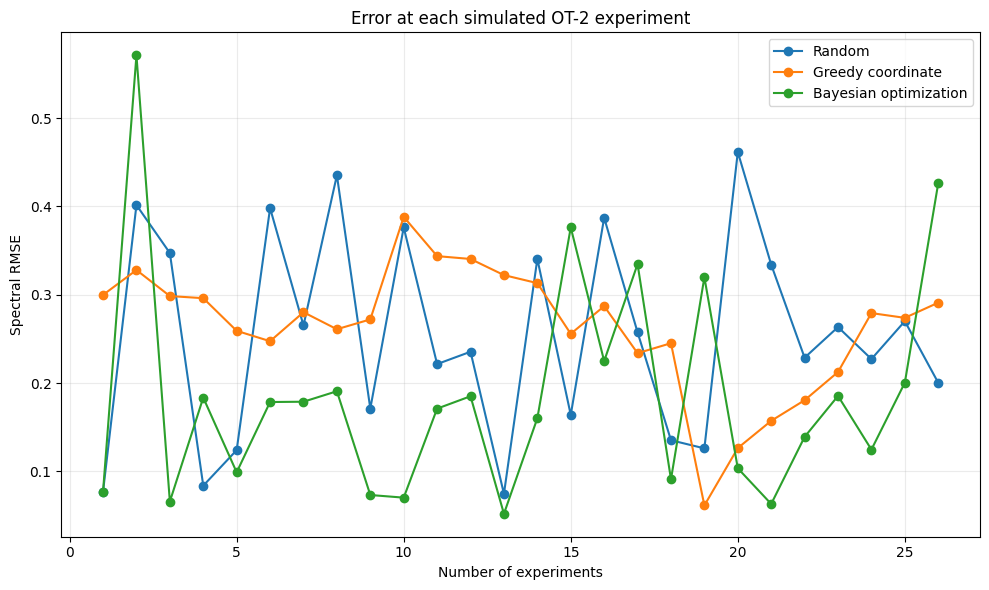

In [ ]:
plt.figure(figsize=(10, 6))
for df, label in [
    (random_df, "Random"),
    (greedy_df, "Greedy coordinate"),
    (bayes_df, "Bayesian optimization"),
]:
    plt.plot(df["iteration"], df["rmse"], marker="o", label=label)

plt.xlabel("Number of experiments")
plt.ylabel("Spectral RMSE")
plt.title("Error at each simulated OT-2 experiment")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

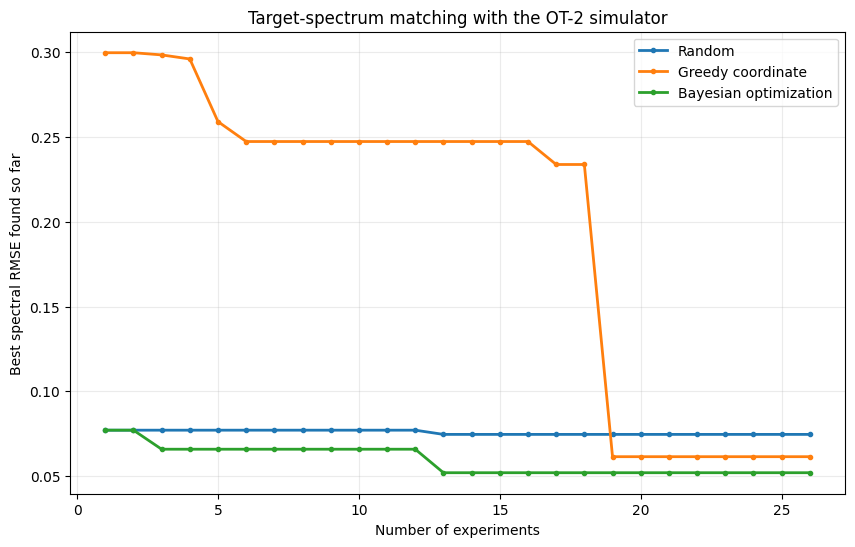

In [ ]:
comparison_df = pd.concat([random_df, greedy_df, bayes_df], ignore_index=True)

plt.figure(figsize=(10, 6))
for method, group in comparison_df.groupby("method", sort=False):
    plt.plot(
        group["iteration"],
        group["best_so_far"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=method,
    )

plt.xlabel("Number of experiments")
plt.ylabel("Best spectral RMSE found so far")
plt.title("Target-spectrum matching with the OT-2 simulator")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

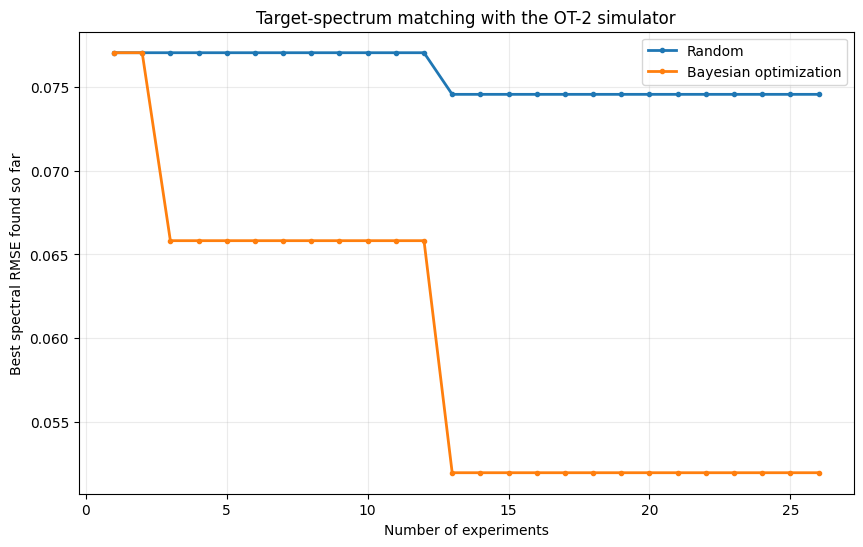

In [ ]:
comparison_df = pd.concat([random_df, bayes_df], ignore_index=True)

plt.figure(figsize=(10, 6))

for method, group in comparison_df.groupby("method", sort=False):
    plt.plot(
        group["iteration"],
        group["best_so_far"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=method,
    )

plt.xlabel("Number of experiments")
plt.ylabel("Best spectral RMSE found so far")
plt.title("Target-spectrum matching with the OT-2 simulator")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
def best_row(df):
    row = df.loc[df["rmse"].idxmin()]
    return {
        "Best R (µL)": int(row["R"]),
        "Best Y (µL)": int(row["Y"]),
        "Best B (µL)": int(row["B"]),
        "Best error": float(row["rmse"]),
        "First reached at experiment": int(row["iteration"]),
    }


summary = pd.DataFrame({
    "Random": best_row(random_df),
    "Greedy coordinate": best_row(greedy_df),
    "Bayesian optimization": best_row(bayes_df),
}).T
summary

,Best R (µL),Best Y (µL),Best B (µL),Best error,First reached at experiment
Random,72.0,170.0,16.0,0.074571,13.0
Greedy coordinate,66.0,118.0,10.0,0.061414,19.0
Bayesian optimization,135.0,152.0,10.0,0.051953,13.0


## 7. What should be taken away?

The three methods use the same experimental budget in fundamentally different ways.

**Random sampling** explores broadly but does not learn from good or bad measurements.

**Greedy coordinate search** uses measurements to keep better settings, but it changes one liquid volume at a time and can miss interactions between colors.

**Bayesian optimization** uses all previous observations jointly. The Gaussian Process estimates both expected error and uncertainty across the feasible liquid-mixture space, while Expected Improvement decides which simulated OT-2 experiment is most informative to run next.

The essential closed loop is

$
\boxed{\text{simulate} \rightarrow \text{fit surrogate} \rightarrow \text{select next mixture} \rightarrow \text{simulate again}}.
$

## 9. Can you beat this implementation?

So far, the Bayesian optimization setup uses:

- an RBF Gaussian Process;
- Expected Improvement;
- five random initial experiments;
- a fixed 26-experiment budget;
- one objective: minimize the spectral RMSE to the target spectrum.

Try changing the optimization strategy while keeping the OT-2 simulator, constraints, target, and experimental budget fixed.

### 9.1 Tune the Gaussian Process

The Gaussian Process models

$
(R,Y,B) \longrightarrow \text{spectral RMSE}.
$

The length scale controls how quickly the model believes the objective can change as the liquid mixture changes.

- A **larger** length scale assumes a smoother response.
- A **smaller** length scale allows more rapid changes.



In [ ]:
length_scales_to_try = [0.10, 0.25, 0.50]
for ls in length_scales_to_try:
    print(f"Try normalized length_scale = {ls}")

Try normalized length_scale = 0.1
Try normalized length_scale = 0.25
Try normalized length_scale = 0.5


#### Change the GP noise level

The simulator contains sensor noise, so the objective is not perfectly deterministic. The Gaussian Process noise parameter controls how strongly the surrogate tries to fit every observation exactly.

In [ ]:
alpha_values = [1e-6, 1e-4, 1e-2]
for alpha in alpha_values:
    print(f"Try alpha = {alpha}")

Try alpha = 1e-06
Try alpha = 0.0001
Try alpha = 0.01


#### Try a Matérn kernel

The RBF kernel assumes a very smooth objective. A Matérn kernel can represent a rougher response surface.

In [ ]:
from sklearn.gaussian_process.kernels import Matern

matern_kernel = Matern(
    length_scale=[0.25, 0.25, 0.25],
    nu=2.5,
)
matern_kernel

Matern(length_scale=[0.25, 0.25, 0.25], nu=2.5)

### 9.2 Modify Expected Improvement

Expected Improvement balances promising predictions and uncertainty. The parameter $\xi$ changes this balance.

Increasing $\xi$ can encourage the optimizer to consider more uncertain regions rather than repeatedly sampling near the current best mixture.

In [ ]:
xi_values = [0.001, 0.01, 0.10]
for xi in xi_values:
    print(f"Try xi = {xi}")

Try xi = 0.001
Try xi = 0.01
Try xi = 0.1


You can also change exploration during the campaign. For example, use more exploration early and more exploitation later.

In [ ]:
def xi_schedule(iteration, total_iterations):
    return max(0.001, 0.10 * (1.0 - iteration / total_iterations))

for t in range(0, NUM_EXPERIMENTS, 5):
    print(f"iteration {t:2d}: xi = {xi_schedule(t, NUM_EXPERIMENTS):.4f}")

iteration  0: xi = 0.1000
iteration  5: xi = 0.0808
iteration 10: xi = 0.0615
iteration 15: xi = 0.0423
iteration 20: xi = 0.0231
iteration 25: xi = 0.0038


### 9.3 Other acquisition strategies

**Gaussian Process Lower Confidence Bound (GP-LCB)** for minimization selects

$
\mathbf{x}_{\mathrm{next}}
=
\arg\min_{\mathbf{x}}\left[\mu(\mathbf{x})-\kappa\sigma(\mathbf{x})\right].
$

**Probability of Improvement (PI)** selects points based on the probability of beating the current best result.

**Thompson Sampling** samples one plausible objective function from the GP posterior and optimizes that sampled function.

These strategies use uncertainty differently, so they may behave differently under the same simulated OT-2 budget.

In [ ]:
kappa_values = [0.5, 2.0, 5.0]
for kappa in kappa_values:
    print(f"Try kappa = {kappa}")

Try kappa = 0.5
Try kappa = 2.0
Try kappa = 5.0


## 10. Final challenge

Compare several optimizer variants while keeping the **same target, simulator, constraints, and 26-experiment budget**.

| Experiment | Surrogate | Acquisition / strategy |
|---|---|---|
| A | RBF GP | Expected Improvement |
| B | Matérn GP | Expected Improvement |
| C | ARD Matérn GP | Expected Improvement |
| D | ARD Matérn GP | More exploratory EI |
| E | GP | Lower Confidence Bound |
| F | GP | Probability of Improvement |
| G | GP | Thompson Sampling |

Compare them using

$
\boxed{\text{best spectral RMSE found so far}}
$

versus

$
\boxed{\text{number of simulated OT-2 experiments}}.
$

The central question is not only which optimizer finds the smallest error, but **which optimizer finds a good spectrum match using the fewest experiments**.

In [ ]:
challenge_results = pd.DataFrame(
    columns=[
        "method",
        "kernel",
        "acquisition",
        "hyperparameters",
        "best_rmse",
        "experiment_where_best_was_found",
    ]
)
challenge_results

,method,kernel,acquisition,hyperparameters,best_rmse,experiment_where_best_was_found
